# 04 — Robustness Checks

Permutation test, negative control verification, and sensitivity analysis.

**Science check:** Do NOT interpret any finding until all three checks have been run.

In [1]:
import sys
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '..')

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Reload Data and Fitted Model

In [2]:
from src.features.pipeline import get_early_session_features, get_late_session_features
from src.modelling.evaluation import label_high_dependency
from src.modelling.main_model import build_pipeline, add_negative_control

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(PROJECT_ROOT, 'data', 'processed', 'feature_matrix.parquet')):
    PROJECT_ROOT = os.getcwd()

FIGURES_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures')
TABLES_DIR  = os.path.join(PROJECT_ROOT, 'outputs', 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

feature_matrix = pd.read_parquet(os.path.join(PROJECT_ROOT, 'data', 'processed', 'feature_matrix.parquet'))

early  = get_early_session_features(feature_matrix)
late   = get_late_session_features(feature_matrix)
labels = label_high_dependency(late, min_criteria=2)

early_indexed = early.set_index('hashed_ip')
y_aligned     = labels.reindex(early_indexed.index)
valid_mask    = y_aligned.notna()
X_early       = early_indexed[valid_mask]
y             = y_aligned[valid_mask].astype(int).values

X_with_control = add_negative_control(X_early)
feature_names  = list(X_with_control.columns)
X_arr          = X_with_control.values
user_ids       = np.array(X_with_control.index)

print(f'N users: {len(y):,}  |  Positive rate: {y.mean():.2%}')

N users: 12,497  |  Positive rate: 24.12%


## 2. Permutation Test

In [3]:
from src.modelling.evaluation import cross_validate_model, run_permutation_test

pipeline   = build_pipeline(penalty='l1', C=1.0, random_state=RANDOM_SEED)
cv_results = cross_validate_model(pipeline, X_arr, y, user_ids, n_folds=10)
observed_auc = cv_results['observed_auc']
print(f'Observed AUC (10-fold CV pooled): {observed_auc:.3f}')

perm_results = run_permutation_test(pipeline, X_arr, y, observed_auc, n_permutations=1000, random_state=RANDOM_SEED)
print(f'Permutation p-value:              {perm_results["p_value"]:.4f}')
print(f'Significant at α=.05:             {perm_results["significant_at_05"]}')

Observed AUC (10-fold CV pooled): 0.712


Permutation p-value:              0.0000
Significant at α=.05:             True


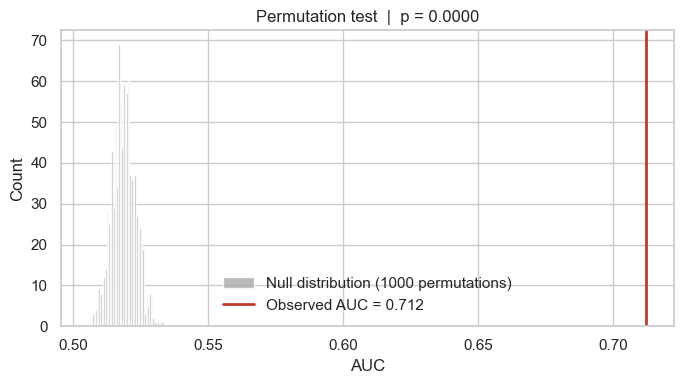

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_results['null_aucs'], bins=50, color='#AAAAAA', alpha=0.8, label='Null distribution (1000 permutations)')
ax.axvline(observed_auc, color='#C0392B', linewidth=2, label=f'Observed AUC = {observed_auc:.3f}')
ax.set_xlabel('AUC')
ax.set_ylabel('Count')
ax.set_title(f'Permutation test  |  p = {perm_results["p_value"]:.4f}')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_permutation_test.png'), dpi=150)
plt.show()

## 3. Negative Control Check

In [5]:
from src.modelling.main_model import get_feature_importances, NEGATIVE_CONTROL_FEATURE

pipeline.fit(X_arr, y)
importances = get_feature_importances(pipeline, feature_names)

nc_row  = importances[importances['feature'] == NEGATIVE_CONTROL_FEATURE]
nc_rank = nc_row.index[0] + 1
nc_coef = nc_row['coefficient'].iloc[0]

print(f'Negative control ({NEGATIVE_CONTROL_FEATURE}):')
print(f'  Rank:        {nc_rank} of {len(importances)}')
print(f'  Coefficient: {nc_coef:.4f}')

if nc_rank <= 3:
    print('WARNING: Negative control is in top 3 — reconsider the model')
else:
    print('Negative control check PASSED')

importances

Negative control (punctuation_rate):
  Rank:        14 of 15
  Coefficient: -0.0181
Negative control check PASSED


,feature,coefficient,abs_coef
0,log_n_user_turns,0.688103,0.688103
1,log_return_interval_hours,-0.345783,0.345783
2,fpp_rate,0.286465,0.286465
3,refusal_resistance_rate,0.195655,0.195655
4,n_user_turns,-0.170643,0.170643
5,filler_rate,0.139832,0.139832
6,hedging_rate,0.129071,0.129071
7,question_to_statement_ratio,0.067741,0.067741
8,type_token_ratio,-0.040855,0.040855
9,mean_message_length,0.033276,0.033276


## 4. Sensitivity Analysis (Label Threshold)

Threshold ≥1: n_pos=8,927  AUC=0.690±0.015  top3=['log_return_interval_hours', 'return_interval_hours', 'n_user_turns']


Threshold ≥2: n_pos=3,014  AUC=0.712±0.014  top3=['log_n_user_turns', 'log_return_interval_hours', 'fpp_rate']


Threshold ≥3: n_pos=720  AUC=0.748±0.041  top3=['log_n_user_turns', 'fpp_rate', 'log_return_interval_hours']
Threshold 4: pos_rate=0.66% — skipping (too imbalanced)


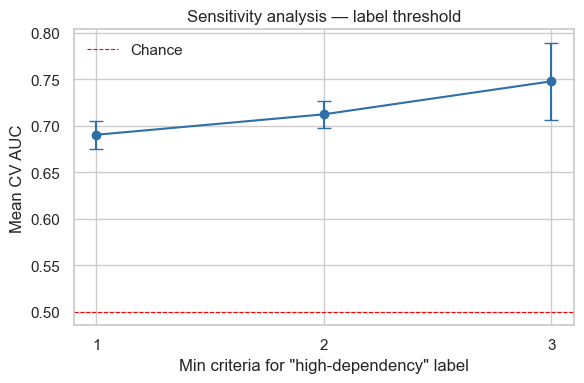

,threshold,n_positive,pos_rate,mean_auc,std_auc,top3_features
0,1,8927,0.7143,0.6904,0.0149,"log_return_interval_hours, return_interval_hou..."
1,2,3014,0.2412,0.7124,0.0145,"log_n_user_turns, log_return_interval_hours, f..."
2,3,720,0.0576,0.7479,0.0414,"log_n_user_turns, fpp_rate, log_return_interva..."


In [6]:
warnings.filterwarnings('ignore')

sensitivity_records = []
top3_by_threshold   = {}

for threshold in [1, 2, 3, 4]:
    labels_t  = label_high_dependency(late, min_criteria=threshold)
    y_t       = labels_t.reindex(early_indexed.index)
    y_t_valid = y_t[valid_mask].astype(int).values

    pos_rate = y_t_valid.mean()
    if pos_rate < 0.02 or pos_rate > 0.98:
        print(f'Threshold {threshold}: pos_rate={pos_rate:.2%} — skipping (too imbalanced)')
        continue

    pipeline_t = build_pipeline(penalty='l1', C=1.0, random_state=RANDOM_SEED)
    cv_t       = cross_validate_model(pipeline_t, X_arr, y_t_valid, user_ids, n_folds=10)

    pipeline_t.fit(X_arr, y_t_valid)
    imp_t  = get_feature_importances(pipeline_t, feature_names)
    top3   = imp_t.head(3)['feature'].tolist()
    top3_by_threshold[threshold] = top3

    sensitivity_records.append({
        'threshold': threshold,
        'n_positive': int(y_t_valid.sum()),
        'pos_rate':   round(pos_rate, 4),
        'mean_auc':   round(cv_t['mean_auc'], 4),
        'std_auc':    round(cv_t['std_auc'],  4),
        'top3_features': ', '.join(top3),
    })
    print(f'Threshold ≥{threshold}: n_pos={y_t_valid.sum():,}  AUC={cv_t["mean_auc"]:.3f}±{cv_t["std_auc"]:.3f}  top3={top3}')

sensitivity_df = pd.DataFrame(sensitivity_records)
sensitivity_df.to_csv(os.path.join(TABLES_DIR, 'sensitivity_analysis.csv'), index=False)

# AUC stability plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(sensitivity_df['threshold'], sensitivity_df['mean_auc'],
            yerr=sensitivity_df['std_auc'], fmt='o-', color='#2E6FA8', capsize=5)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='Chance')
ax.set_xlabel('Min criteria for "high-dependency" label')
ax.set_ylabel('Mean CV AUC')
ax.set_title('Sensitivity analysis — label threshold')
ax.legend(frameon=False)
ax.set_xticks(sensitivity_df['threshold'])
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_sensitivity_auc.png'), dpi=150)
plt.show()

sensitivity_df